In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
data = pd.read_csv(
    "Objective2_L1.csv"
)

data["Date"] = pd.to_datetime(
    data["Date"],
    dayfirst=True
)

data = data.sort_values(
    "Match_ID"
).reset_index(drop=True)

display(data.head())

print("Dataset shape:", data.shape)
print("\nMissing values:")
print(data.isnull().sum())

,Match_ID,Date,Round,Team1,Team2,Team1_Fouls,Team2_Fouls,Extra_Time,Stage,Total_Fouls,Team1_Goals,Team2_Goals,Goal_Difference
0,1,2026-06-11,Group Stage,Mexico,South Africa,12.0,11.0,False,Group Stage,23.0,2,0,2
1,2,2026-06-12,Group Stage,South Korea,Czech Republic,9.0,16.0,False,Group Stage,25.0,2,1,1
2,3,2026-06-12,Group Stage,Canada,Bosnia & Herzegovina,10.0,20.0,False,Group Stage,30.0,1,1,0
3,4,2026-06-13,Group Stage,USA,Paraguay,13.0,17.0,False,Group Stage,30.0,4,1,3
4,5,2026-06-13,Group Stage,Qatar,Switzerland,12.0,11.0,False,Group Stage,23.0,1,1,0


Dataset shape: (104, 13)

Missing values:
Match_ID           0
Date               0
Round              0
Team1              0
Team2              0
Team1_Fouls        1
Team2_Fouls        1
Extra_Time         0
Stage              0
Total_Fouls        1
Team1_Goals        0
Team2_Goals        0
Goal_Difference    0
dtype: int64


In [3]:
data["Goal_Difference"] = (
    data["Team1_Goals"]
    -
    data["Team2_Goals"]
)

display(
    data[
        [
            "Match_ID",
            "Team1",
            "Team1_Goals",
            "Team2_Goals",
            "Team2",
            "Goal_Difference"
        ]
    ].head(10)
)

,Match_ID,Team1,Team1_Goals,Team2_Goals,Team2,Goal_Difference
0,1,Mexico,2,0,South Africa,2
1,2,South Korea,2,1,Czech Republic,1
2,3,Canada,1,1,Bosnia & Herzegovina,0
3,4,USA,4,1,Paraguay,3
4,5,Qatar,1,1,Switzerland,0
5,6,Brazil,1,1,Morocco,0
6,7,Haiti,0,1,Scotland,-1
7,8,Australia,2,0,Turkey,2
8,9,Germany,7,1,Curacao,6
9,10,Netherlands,2,2,Japan,0


In [4]:
team_state = {}

def new_team_state():
    return {
        "matches": 0,
        "goals_for": 0,
        "goals_against": 0,
        "wins": 0,
        "clean_sheets": 0,
        "failed_to_score": 0,
        "fouls_sum": 0,
        "foul_matches": 0,
        "last_date": None
    }


def get_pre_match_stats(team, match_date):

    if team not in team_state:
        team_state[team] = new_team_state()

    state = team_state[team]

    if state["matches"] == 0:

        avg_gf = 0
        avg_ga = 0
        win_rate = 0
        clean_sheet_rate = 0
        failed_to_score_rate = 0

    else:

        avg_gf = (
            state["goals_for"]
            / state["matches"]
        )

        avg_ga = (
            state["goals_against"]
            / state["matches"]
        )

        win_rate = (
            state["wins"]
            / state["matches"]
        )

        clean_sheet_rate = (
            state["clean_sheets"]
            / state["matches"]
        )

        failed_to_score_rate = (
            state["failed_to_score"]
            / state["matches"]
        )

    if state["foul_matches"] == 0:
        avg_fouls = 0
    else:
        avg_fouls = (
            state["fouls_sum"]
            / state["foul_matches"]
        )

    if state["last_date"] is None:
        rest_days = 0
    else:
        rest_days = (
            match_date
            - state["last_date"]
        ).days

    return {
        "avg_gf": avg_gf,
        "avg_ga": avg_ga,
        "win_rate": win_rate,
        "clean_sheet_rate": clean_sheet_rate,
        "failed_to_score_rate": failed_to_score_rate,
        "avg_fouls": avg_fouls,
        "rest_days": rest_days
    }


def update_team_state(
    team,
    goals_for,
    goals_against,
    fouls,
    match_date
):

    state = team_state[team]

    state["matches"] += 1
    state["goals_for"] += goals_for
    state["goals_against"] += goals_against

    if goals_for > goals_against:
        state["wins"] += 1

    if goals_against == 0:
        state["clean_sheets"] += 1

    if goals_for == 0:
        state["failed_to_score"] += 1

    if pd.notna(fouls):
        state["fouls_sum"] += fouls
        state["foul_matches"] += 1

    state["last_date"] = match_date

In [5]:
regression_rows = []

for _, match in data.iterrows():

    team1 = match["Team1"]
    team2 = match["Team2"]

    match_date = match["Date"]

    team1_pre = get_pre_match_stats(
        team1,
        match_date
    )

    team2_pre = get_pre_match_stats(
        team2,
        match_date
    )

    row = {
        "Match_ID": match["Match_ID"],

        "Team1": team1,
        "Team2": team2,

        "Goal_Difference":
            match["Goal_Difference"],

        "Avg_GF_Diff":
            team1_pre["avg_gf"]
            -
            team2_pre["avg_gf"],

        "Avg_GA_Diff":
            team1_pre["avg_ga"]
            -
            team2_pre["avg_ga"],

        "Win_Rate_Diff":
            team1_pre["win_rate"]
            -
            team2_pre["win_rate"],

        "Clean_Sheet_Rate_Diff":
            team1_pre["clean_sheet_rate"]
            -
            team2_pre["clean_sheet_rate"],

        "Failed_To_Score_Rate_Diff":
            team1_pre["failed_to_score_rate"]
            -
            team2_pre["failed_to_score_rate"],

        "Avg_Fouls_Diff":
            team1_pre["avg_fouls"]
            -
            team2_pre["avg_fouls"],

        "Rest_Days_Diff":
            team1_pre["rest_days"]
            -
            team2_pre["rest_days"],

        "Knockout_Indicator":
            1 if match["Stage"] == "Knockout"
            else 0
    }

    regression_rows.append(row)

    # Update AFTER creating pre-match variables
    update_team_state(
        team1,
        match["Team1_Goals"],
        match["Team2_Goals"],
        match["Team1_Fouls"],
        match_date
    )

    update_team_state(
        team2,
        match["Team2_Goals"],
        match["Team1_Goals"],
        match["Team2_Fouls"],
        match_date
    )


regression_data = pd.DataFrame(
    regression_rows
)

display(regression_data.head(15))

print(
    "Regression dataset shape:",
    regression_data.shape
)

,Match_ID,Team1,Team2,Goal_Difference,Avg_GF_Diff,Avg_GA_Diff,Win_Rate_Diff,Clean_Sheet_Rate_Diff,Failed_To_Score_Rate_Diff,Avg_Fouls_Diff,Rest_Days_Diff,Knockout_Indicator
0,1,Mexico,South Africa,2,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2,South Korea,Czech Republic,1,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,3,Canada,Bosnia & Herzegovina,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,4,USA,Paraguay,3,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,5,Qatar,Switzerland,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
5,6,Brazil,Morocco,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
6,7,Haiti,Scotland,-1,0.0,0.0,0.0,0.0,0.0,0.0,0,0
7,8,Australia,Turkey,2,0.0,0.0,0.0,0.0,0.0,0.0,0,0
8,9,Germany,Curacao,6,0.0,0.0,0.0,0.0,0.0,0.0,0,0
9,10,Netherlands,Japan,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


Regression dataset shape: (104, 12)


In [6]:
features = [
    "Avg_GF_Diff",
    "Avg_GA_Diff",
    "Win_Rate_Diff",
    "Clean_Sheet_Rate_Diff",
    "Failed_To_Score_Rate_Diff",
    "Avg_Fouls_Diff",
    "Rest_Days_Diff",
    "Knockout_Indicator"
]

print(
    "Number of explanatory variables:",
    len(features)
)

print("\nExplanatory variables:")

for feature in features:
    print(feature)

Number of explanatory variables: 8

Explanatory variables:
Avg_GF_Diff
Avg_GA_Diff
Win_Rate_Diff
Clean_Sheet_Rate_Diff
Failed_To_Score_Rate_Diff
Avg_Fouls_Diff
Rest_Days_Diff
Knockout_Indicator


In [7]:
print(
    regression_data[
        features
        +
        ["Goal_Difference"]
    ].isnull().sum()
)

display(
    regression_data[
        features
        +
        ["Goal_Difference"]
    ].describe().round(2)
)

Avg_GF_Diff                  0
Avg_GA_Diff                  0
Win_Rate_Diff                0
Clean_Sheet_Rate_Diff        0
Failed_To_Score_Rate_Diff    0
Avg_Fouls_Diff               0
Rest_Days_Diff               0
Knockout_Indicator           0
Goal_Difference              0
dtype: int64


,Avg_GF_Diff,Avg_GA_Diff,Win_Rate_Diff,Clean_Sheet_Rate_Diff,Failed_To_Score_Rate_Diff,Avg_Fouls_Diff,Rest_Days_Diff,Knockout_Indicator,Goal_Difference
count,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,0.07,-0.18,0.03,0.02,-0.02,-0.32,-0.02,0.31,0.47
std,1.33,1.27,0.39,0.44,0.39,3.33,0.90,0.46,2.03
min,-4.50,-6.00,-1.00,-1.00,-1.00,-13.00,-2.00,0.00,-4.00
25%,-0.50,-0.69,0.00,0.00,0.00,-1.50,-1.00,0.00,-1.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.81,0.21,0.00,0.21,0.00,1.00,1.00,1.00,2.00
max,6.00,3.00,1.00,1.00,1.00,8.00,4.00,1.00,6.00


In [8]:
regression_data.to_csv(
    "objective2_regression_2_1_dataset.csv",
    index=False
)

print(
    "Regression 2.1 dataset saved."
)

Regression 2.1 dataset saved.


In [9]:
X = regression_data[
    features
]

y = regression_data[
    "Goal_Difference"
]

In [10]:
split_index = int(
    len(regression_data) * 0.80
)

X_train = X.iloc[
    :split_index
]

X_test = X.iloc[
    split_index:
]

y_train = y.iloc[
    :split_index
]

y_test = y.iloc[
    split_index:
]

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

Training rows: 83
Testing rows: 21


In [11]:
model_21 = LinearRegression()

model_21.fit(
    X_train,
    y_train
)

predictions = model_21.predict(
    X_test
)

In [12]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(
    "MAE:",
    round(mae, 3)
)

print(
    "RMSE:",
    round(rmse, 3)
)

print(
    "R-squared:",
    round(r2, 3)
)

MAE: 1.518
RMSE: 1.971
R-squared: -0.657


In [13]:
coefficients = pd.DataFrame(
    {
        "Variable": features,
        "Coefficient":
            model_21.coef_
    }
)

coefficients = coefficients.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

display(
    coefficients.round(3)
)

print(
    "Intercept:",
    round(
        model_21.intercept_,
        3
    )
)

,Variable,Coefficient
3,Clean_Sheet_Rate_Diff,1.054
2,Win_Rate_Diff,-0.837
6,Rest_Days_Diff,0.523
4,Failed_To_Score_Rate_Diff,-0.441
1,Avg_GA_Diff,-0.409
0,Avg_GF_Diff,0.345
7,Knockout_Indicator,-0.318
5,Avg_Fouls_Diff,-0.121


Intercept: 0.666


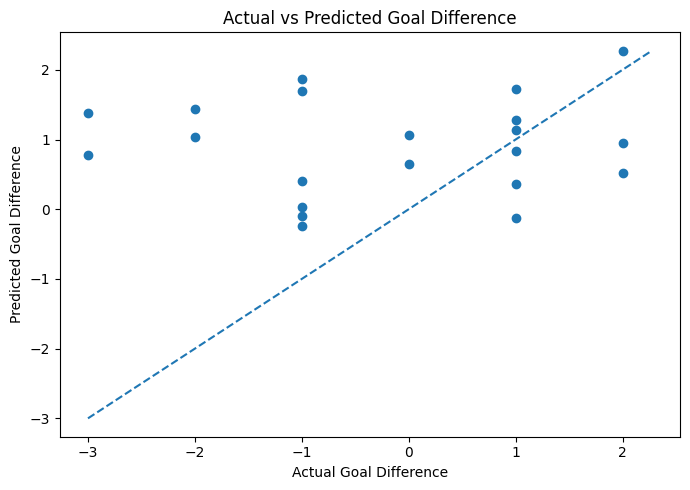

In [14]:
plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    y_test,
    predictions
)

minimum = min(
    y_test.min(),
    predictions.min()
)

maximum = max(
    y_test.max(),
    predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Goal Difference"
)

plt.ylabel(
    "Predicted Goal Difference"
)

plt.title(
    "Actual vs Predicted Goal Difference"
)

plt.tight_layout()
plt.show()

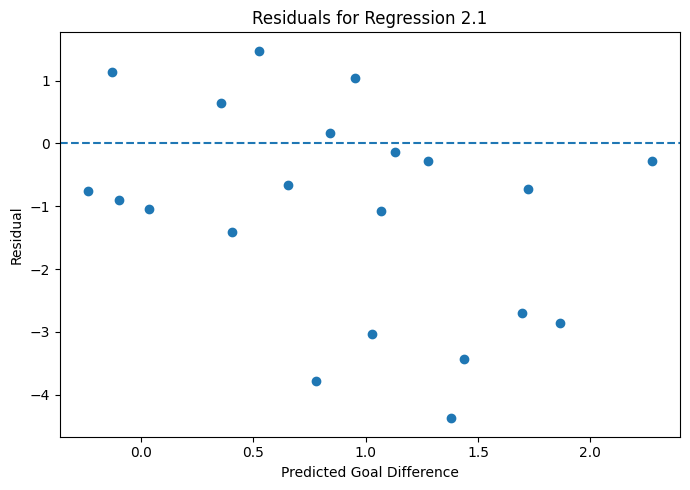

In [15]:
residuals = (
    y_test
    -
    predictions
)

plt.figure(
    figsize=(7, 5)
)

plt.scatter(
    predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Goal Difference"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals for Regression 2.1"
)

plt.tight_layout()
plt.show()

In [16]:
baseline_predictions = np.repeat(
    y_train.mean(),
    len(y_test)
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R-squared:", round(baseline_r2, 3))

Baseline MAE: 1.425
Baseline RMSE: 1.741
Baseline R-squared: -0.293
